# **Step-1: Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [4]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras import layers
from keras.layers import Dense
from keras.layers import Dropout
from keras.utils import to_categorical

# **Step-2: Load Dataset**

In [7]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# **Step-3: EDA**

*  **Basic Data Understanding**



In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [10]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6413,7739-LAXOG,Female,0,Yes,Yes,32,Yes,Yes,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),91.05,2954.5,Yes
918,6103-BOCOU,Female,0,No,No,26,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,80.70,2193,No
6484,2911-IJORQ,Male,0,No,No,37,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),90.60,3358.65,No
5432,1597-FZREH,Female,0,No,No,2,Yes,No,DSL,No,...,Yes,Yes,Yes,Yes,Month-to-month,No,Electronic check,76.40,160.8,Yes
1658,1228-FZFRV,Male,0,Yes,Yes,50,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,Yes,Month-to-month,No,Credit card (automatic),105.95,5341.8,Yes


In [11]:
df.shape

(7043, 21)

In [12]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [15]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


*  **Check Missing Values**

In [16]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


*   **Checking Duplicated Values**



In [17]:
df.duplicated().sum()

np.int64(0)

*   **Checking Data Types**



In [18]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [19]:
df["TotalCharges"].dtype

dtype('O')

In [20]:
df["TotalCharges"].dtype
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce", )
df["TotalCharges"].dtype

dtype('float64')

In [21]:
df["TotalCharges"].dtype

dtype('float64')

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.shape

(7043, 21)

* **Univarite Analysis**



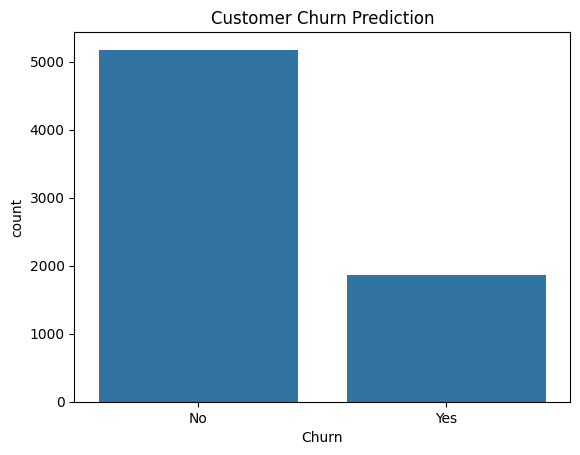

In [24]:
sns.countplot(data = df, x = "Churn")
plt.title("Customer Churn Prediction")
plt.show()

*  **Bivariate Analysis**



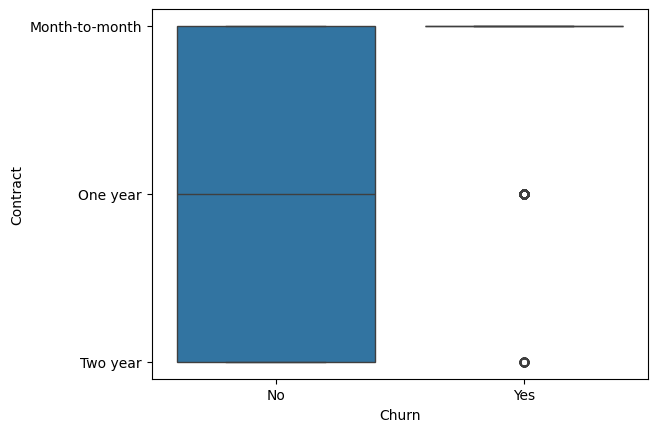

In [25]:
sns.boxplot(data = df, x = "Churn", y = "Contract")
plt.xlabel("Churn")
plt.ylabel("Contract")
plt.show()

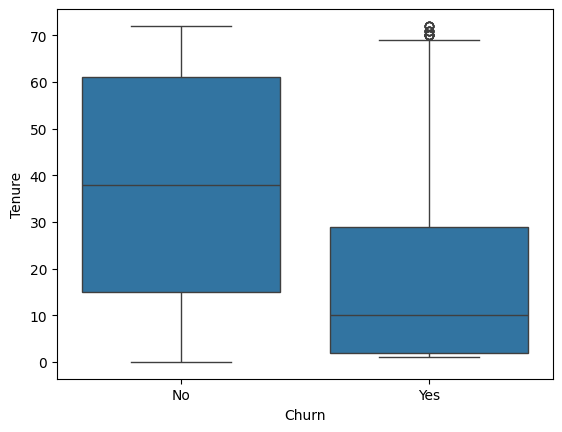

In [26]:
sns.boxplot(data = df, x = "Churn", y = "tenure")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

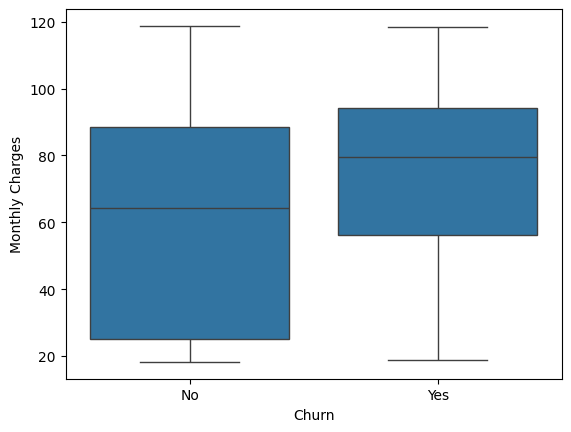

In [27]:
sns.boxplot(data = df, x = "Churn", y = "MonthlyCharges")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

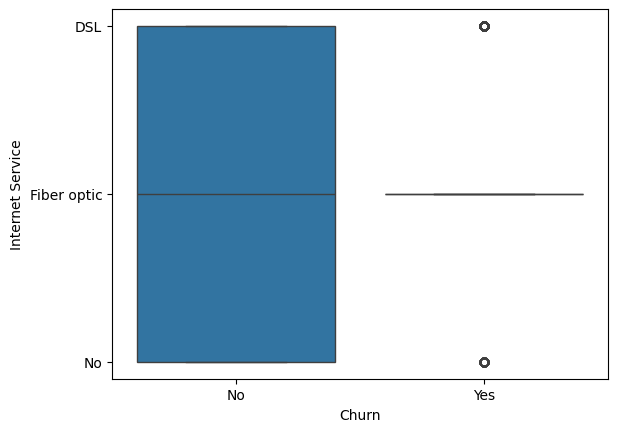

In [28]:
sns.boxplot(data = df, x = "Churn", y = "InternetService")
plt.xlabel("Churn")
plt.ylabel("Internet Service")
plt.show()

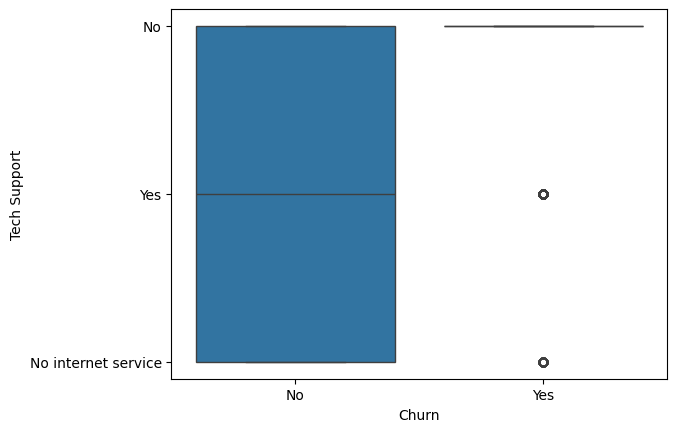

In [29]:
sns.boxplot(data = df, x = "Churn", y = "TechSupport")
plt.xlabel("Churn")
plt.ylabel("Tech Support")
plt.show()

# **Step-4: Data Cleaning**

In [30]:
df_copy = df.copy()

In [31]:
df_copy.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [32]:
df_copy.dropna(inplace = True)

In [33]:
df_copy.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [34]:
df_copy.drop("customerID", axis=1, inplace=True)

# **Step-5: Data Preprocessing**

*  **Train-Test Split**



In [35]:
X = df_copy.drop("Churn", axis = 1)
y = df_copy["Churn"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [37]:
df_copy.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


* **Encoding Categorical Columns**



In [38]:
categorical_cols = X_train.select_dtypes(include="object").columns

In [39]:
categorical_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [40]:
encoder = OneHotEncoder()

In [41]:
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

In [42]:
new_column_names = encoder.get_feature_names_out(categorical_cols)

In [43]:
new_column_names

array(['gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes',
       'Dependents_No', 'Dependents_Yes', 'PhoneService_No',
       'PhoneService_Yes', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_No',
       'PaperlessBilling_Yes', 'Payment

* **Feature Scaling (Using Standard Scaler)**



In [44]:
# 1. Get the names of the numerical columns
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
# 2. Initialize the StandardScaler
scaler = StandardScaler()
# 3. Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train[numerical_cols])
# 4. Transform the test data (do NOT fit on test data)
X_test_scaled = scaler.transform(X_test[numerical_cols])

In [45]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numerical_cols, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=numerical_cols, index=X_test.index)

In [46]:
# 1. Get the new column names for the one-hot encoded categories
encoded_col_names = encoder.get_feature_names_out(categorical_cols)
# 2. Convert the encoded data back into pandas DataFrames
X_train_encoded_df = pd.DataFrame(
    X_train_encoded.toarray(), # use .toarray() to convert the sparse matrix
    columns=encoded_col_names,
    index=X_train.index        # keep the original index
)
X_test_encoded_df = pd.DataFrame(
    X_test_encoded.toarray(),
    columns=encoded_col_names,
    index=X_test.index
)
# 3. Combine the scaled numerical DataFrames and encoded categorical DataFrames
X_train_complete = pd.concat([X_train_scaled_df, X_train_encoded_df], axis=1)
X_test_complete = pd.concat([X_test_scaled_df, X_test_encoded_df], axis=1)
# 4. View the final complete training dataset!
X_train_complete.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5767,-0.439616,1.325456,-0.161316,0.679395,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
5361,-0.439616,-1.152524,-1.469930,-0.967341,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5745,-0.439616,1.162966,-1.343719,-0.365667,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
6065,-0.439616,1.081721,-1.317148,-0.336787,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
229,-0.439616,0.594249,0.685630,0.811653,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [61]:
y_train = y_train.map({"No": 0, "Yes": 1})
y_test = y_test.map({"No": 0, "Yes": 1})

# **Step-6: Model Selection**

**1- Logistic Regression**

In [62]:
from sklearn.linear_model import LogisticRegression

In [63]:
model_LR = LogisticRegression()

In [64]:
model_LR.fit(X_train_complete, y_train)

LogisticRegression()

In [65]:
y_pred_LR = model_LR.predict(X_test_complete)

In [66]:
accuracy = accuracy_score(y_test, y_pred_LR)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 80.05%


# **2- ANN**

In [67]:
model_ANN = keras.Sequential(
    [
        layers.Input(shape = (X_train_complete.shape[1],)),
        layers.Dense(16, activation = "relu"),
        layers.Dense(8, activation = "relu"),
        layers.Dense(1, activation = "sigmoid")
    ]
)

In [70]:
model_ANN.compile(optimizer = "sgd", loss = "binary_crossentropy", metrics = ["accuracy"])

In [71]:
model_ANN.fit(X_train_complete, y_train, epochs=50, batch_size=32)

Epoch 1/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6701 - loss: 0.6226
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7591 - loss: 0.5063
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7803 - loss: 0.4641
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7916 - loss: 0.4461
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7952 - loss: 0.4366
Epoch 6/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7994 - loss: 0.4317
Epoch 7/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8003 - loss: 0.4278
Epoch 8/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8009 - loss: 0.4251
Epoch 9/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8022 - loss: 0.4233
Epoch 10/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8030 - loss: 0.4218
Epoch 11/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8026 - loss: 0.4206
Epoch 12/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

In [72]:
ann_preds_prob = model_ANN.predict(X_test_complete)
ann_predictions = (ann_preds_prob > 0.5).astype(int)

73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [75]:
print(f"Keras ANN Accuracy: {accuracy_score(y_test, ann_predictions) * 100:.2f}%")

Keras ANN Accuracy: 79.62%
